# Lending Club — Analyse Exploratoire des Données (EDA)
## Prédiction du défaut de paiement

> **Objectif** : Explorer le dataset Lending Club (prêts 2007–2014) pour comprendre les caractéristiques des emprunteurs, identifier les variables liées au défaut de paiement et préparer les données pour la modélisation.

---

## 0. Imports et configuration

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#E8E8E8",
    "grid.linewidth":    0.8,
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
})

BLUE = "#2166AC"
RED  = "#D6604D"
GRAY = "#636363"

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Chargement des données

On télécharge le dataset Lending Club via l'API Kaggle. Il contient l'ensemble des prêts accordés entre 2007 et 2018 avec plus de 150 variables.

In [2]:
path = kagglehub.dataset_download("wordsforthewise/lending-club")
print(f"Fichiers disponibles : {path}")

data = pd.read_csv(
    f"{path}/accepted_2007_to_2018Q4.csv.gz",
    low_memory=False
)

print(f"Dimensions brutes : {data.shape[0]:,} lignes x {data.shape[1]} colonnes")

Fichiers disponibles : C:\Users\User\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3
Dimensions brutes : 2,260,701 lignes x 151 colonnes


---
## 2. Filtrage temporel : 2007–2014

On restreint l'analyse aux prêts émis entre 2007 et 2014. Ce choix garantit que les prêts ont eu suffisamment de temps pour se dénouer (remboursés ou en défaut) et évite le **biais de survie** lié aux prêts récents encore en cours.

In [3]:
data["issue_d"]    = pd.to_datetime(data["issue_d"], format="%b-%Y")
data["issue_year"] = data["issue_d"].dt.year

data = data[
    (data['issue_year'] >= 2007) &
    (data['issue_year'] <= 2014)
].copy()

print(f"Prets conserves (2007-2014) : {len(data):,}")
print("Distribution par annee :")
print(data['issue_year'].value_counts().sort_index().to_string())

Prets conserves (2007-2014) : 466,345
Distribution par annee :
issue_year
2007.0       603
2008.0      2393
2009.0      5281
2010.0     12537
2011.0     21721
2012.0     53367
2013.0    134814
2014.0    235629


---
## 3. Variable cible

La variable cible est `loan_status`. On conserve uniquement deux modalités :
- **Fully Paid (0)** : le prêt a été intégralement remboursé
- **Charged Off (1)** : le prêt est en défaut de paiement

Les prêts encore en cours (`Current`, `Late`, etc.) sont exclus car leur issue est inconnue.

In [4]:
print("Distribution brute de loan_status :")
print(data['loan_status'].value_counts().to_string())

target_map = {"Fully Paid": 0, "Charged Off": 1}
data = data[data['loan_status'].isin(target_map)].copy()
data['target'] = data['loan_status'].map(target_map)
data.drop(columns=['loan_status'], inplace=True)

n_total   = len(data)
n_default = int(data['target'].sum())
print(f"\nApres filtrage :")
print(f"  Total       : {n_total:,}")
print(f"  Fully Paid  : {n_total - n_default:,}  ({(n_total-n_default)/n_total*100:.1f}%)")
print(f"  Charged Off : {n_default:,}  ({n_default/n_total*100:.1f}%)")

Distribution brute de loan_status :
loan_status
Fully Paid                                             374560
Charged Off                                             76499
Current                                                 11925
Does not meet the credit policy. Status:Fully Paid       1988
Does not meet the credit policy. Status:Charged Off       761
Late (31-120 days)                                        337
In Grace Period                                           201
Late (16-30 days)                                          73
Default                                                     1

Apres filtrage :
  Total       : 451,059
  Fully Paid  : 374,560  (83.0%)
  Charged Off : 76,499  (17.0%)


---
## 4. Suppression des variables avec plus de 50% de valeurs manquantes

Les variables avec plus de 50% de valeurs manquantes apportent peu d'information et risquent d'introduire du bruit dans les modèles. On les supprime automatiquement.

Certaines colonnes essentielles (`target`, `issue_d`, `term`) sont protégées.

In [5]:
PROTECTED = ["target", "issue_d", "issue_year", "term"]
missing_pct = data.isnull().mean() * 100
cols_drop_missing = [
    c for c in missing_pct[missing_pct > 50].index
    if c not in PROTECTED
]

print(f"{len(cols_drop_missing)} variables supprimees (>50% NaN) :")
for c in sorted(cols_drop_missing):
    print(f"  {c:<45} {missing_pct[c]:.1f}%")

data.drop(columns=cols_drop_missing, inplace=True)
print(f"\nDimensions : {data.shape[0]:,} x {data.shape[1]}")

58 variables supprimees (>50% NaN) :
  all_util                                      100.0%
  annual_inc_joint                              100.0%
  debt_settlement_flag_date                     98.6%
  deferral_term                                 99.9%
  desc                                          72.6%
  dti_joint                                     100.0%
  hardship_amount                               99.9%
  hardship_dpd                                  99.9%
  hardship_end_date                             99.9%
  hardship_last_payment_amount                  99.9%
  hardship_length                               99.9%
  hardship_loan_status                          99.9%
  hardship_payoff_balance_amount                99.9%
  hardship_reason                               99.9%
  hardship_start_date                           99.9%
  hardship_status                               99.9%
  hardship_type                                 99.9%
  il_util                                 

---
## 5. Suppression des variables à exclure

### 5.1 Data leakage
Certaines variables ne peuvent pas être utilisées comme prédicteurs car elles introduisent un **data leakage** — elles contiennent une information qui ne serait pas disponible au moment de la décision d'octroi du prêt :

| Variable | Raison |
|---|---|
| `grade`, `sub_grade` | Attribuées par Lending Club selon le risque → cible quasi encodée |
| `int_rate` | Directement dérivé du grade → redondant |
| `total_pymnt`, `recoveries`... | Connus **après** l'issue du prêt |

### 5.2 Redondances et identifiants
On supprime aussi les identifiants, les URLs, les champs texte libres et les variables constantes.

In [6]:
LEAKAGE = [
    "grade", "sub_grade", "int_rate",
    "funded_amnt", "funded_amnt_inv",
    "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int",
    "total_rec_late_fee", "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d", "last_credit_pull_d",
    "out_prncp", "out_prncp_inv",
    "id", "member_id", "url", "desc", "title",
    "zip_code", "policy_code", "application_type", "issue_d",
]

existing_leakage = [c for c in LEAKAGE if c in data.columns]
data.drop(columns=existing_leakage, inplace=True)

print(f"{len(existing_leakage)} variables supprimees (leakage/redondance)")
print(f"Dimensions : {data.shape[0]:,} x {data.shape[1]}")
print("\nVariables conservees :")
for c in sorted(data.columns):
    print(f"  {c}")

24 variables supprimees (leakage/redondance)
Dimensions : 451,059 x 70

Variables conservees :
  acc_now_delinq
  acc_open_past_24mths
  addr_state
  annual_inc
  avg_cur_bal
  bc_open_to_buy
  bc_util
  chargeoff_within_12_mths
  collections_12_mths_ex_med
  debt_settlement_flag
  delinq_2yrs
  delinq_amnt
  disbursement_method
  dti
  earliest_cr_line
  emp_length
  emp_title
  fico_range_high
  fico_range_low
  hardship_flag
  home_ownership
  initial_list_status
  inq_last_6mths
  installment
  issue_year
  last_fico_range_high
  last_fico_range_low
  loan_amnt
  mo_sin_old_il_acct
  mo_sin_old_rev_tl_op
  mo_sin_rcnt_rev_tl_op
  mo_sin_rcnt_tl
  mort_acc
  mths_since_recent_bc
  mths_since_recent_inq
  num_accts_ever_120_pd
  num_actv_bc_tl
  num_actv_rev_tl
  num_bc_sats
  num_bc_tl
  num_il_tl
  num_op_rev_tl
  num_rev_accts
  num_rev_tl_bal_gt_0
  num_sats
  num_tl_120dpd_2m
  num_tl_30dpd
  num_tl_90g_dpd_24m
  num_tl_op_past_12m
  open_acc
  pct_tl_nvr_dlq
  percent_bc_gt_75


---
## 6. Analyse Exploratoire des Données (EDA)

L'EDA vise à répondre à deux questions fondamentales :
1. **Y a-t-il des données manquantes ou aberrantes ?**
2. **Quelles variables sont liées au défaut de paiement ?**

In [7]:
global_rate = data['target'].mean() * 100

### 6.1 Évolution temporelle du portefeuille (2007–2014)

Ce graphique montre l'évolution du **volume de prêts accordés** (barres bleues) et du **taux de défaut** (ligne rouge) par année d'émission.

> **Lecture** : On s'attend à observer une croissance du volume après 2010 et un taux de défaut plus élevé pour les millésimes proches de la crise de 2008.

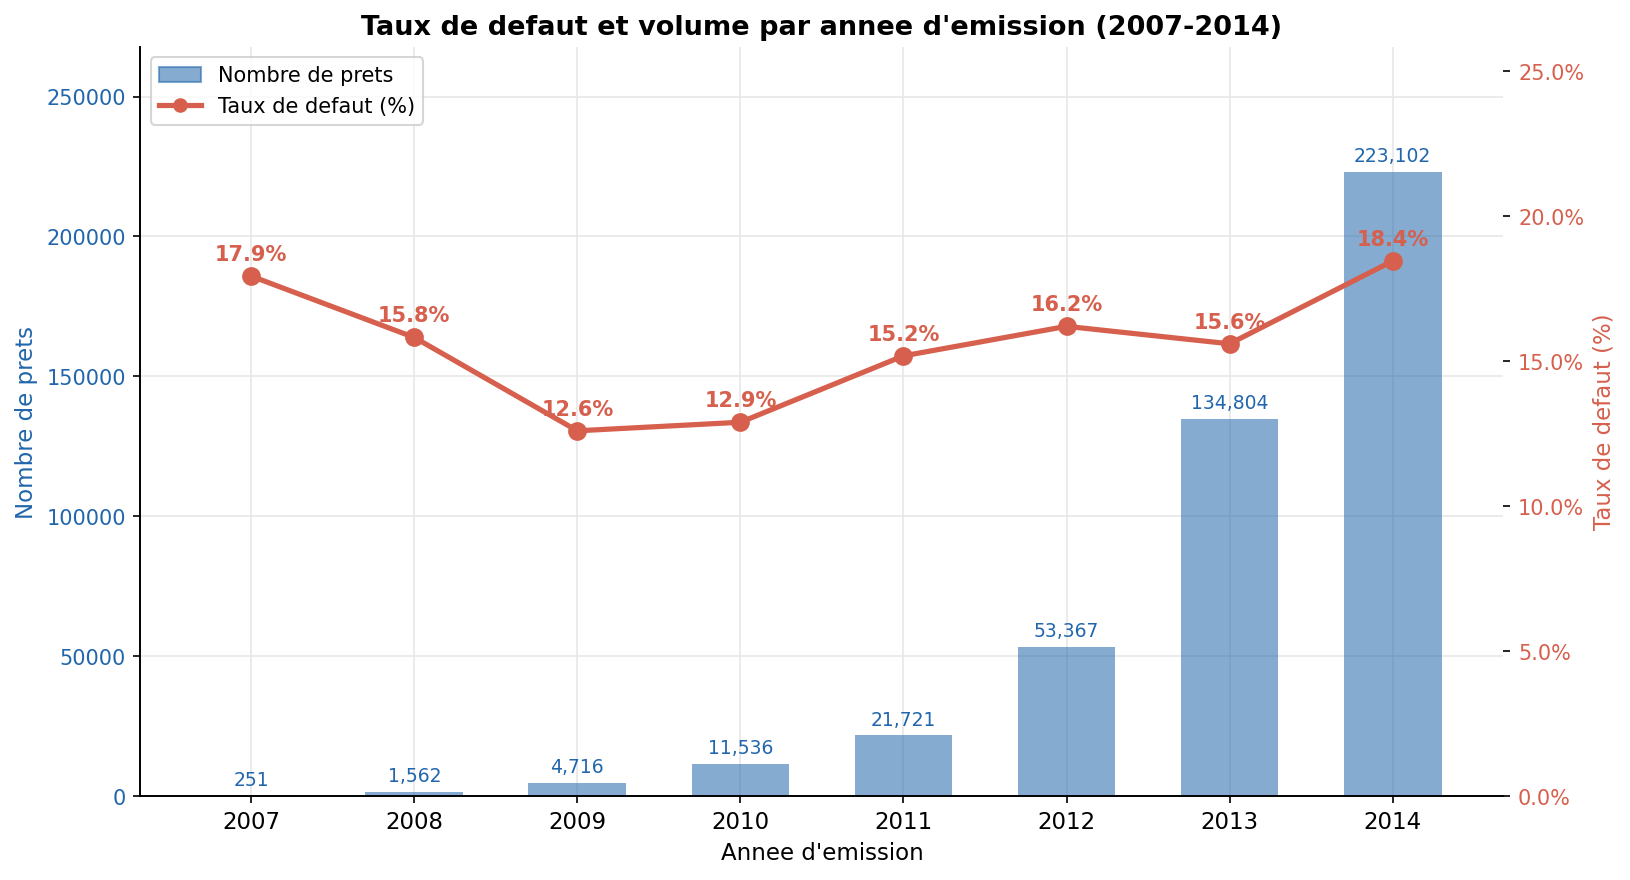

In [8]:
yearly = (
    data.groupby('issue_year')['target']
    .agg(taux_defaut="mean", nb_prets="count")
    .reset_index()
)
yearly['taux_defaut_pct'] = yearly['taux_defaut'] * 100

fig, ax_bar = plt.subplots(figsize=(11, 6))
x = np.arange(len(yearly))
bars = ax_bar.bar(x, yearly['nb_prets'], color=BLUE, alpha=0.55, width=0.6,
                  label='Nombre de prets', zorder=2)
for bar, val in zip(bars, yearly['nb_prets']):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + yearly['nb_prets'].max()*0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=9, color=BLUE)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(yearly['issue_year'].astype(int), fontsize=11)
ax_bar.set_ylabel("Nombre de prets", fontsize=11, color=BLUE)
ax_bar.tick_params(axis='y', labelcolor=BLUE)
ax_bar.set_ylim(0, yearly['nb_prets'].max() * 1.2)

ax_line = ax_bar.twinx()
ax_line.plot(x, yearly['taux_defaut_pct'], color=RED, marker='o',
             markersize=8, linewidth=2.5, label='Taux de defaut (%)', zorder=5)
for xi, val in zip(x, yearly['taux_defaut_pct']):
    ax_line.text(xi, val+0.4, f"{val:.1f}%", ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color=RED, zorder=6)
ax_line.set_ylabel("Taux de defaut (%)", fontsize=11, color=RED)
ax_line.tick_params(axis='y', labelcolor=RED)
ax_line.yaxis.set_major_formatter(mtick.PercentFormatter())
ax_line.set_ylim(0, yearly['taux_defaut_pct'].max() * 1.4)
ax_line.grid(False)

h1 = mpatches.Patch(color=BLUE, alpha=0.55, label='Nombre de prets')
h2 = plt.Line2D([0],[0], color=RED, marker='o', lw=2.5, label='Taux de defaut (%)')
ax_bar.legend(handles=[h1,h2], loc='upper left', fontsize=10)
ax_bar.set_title("Taux de defaut et volume par annee d'emission (2007-2014)")
ax_bar.set_xlabel("Annee d'emission", fontsize=11)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('00_default_by_year.png', bbox_inches='tight', facecolor='white')
plt.show()

data.drop(columns=['issue_year'], inplace=True)

> **Observation** : Le taux de défaut est particulièrement élevé pour les prêts de 2007–2008, période correspondant à la crise financière. Le volume explose à partir de 2012, témoignant de la montée en puissance de la plateforme.

### 6.2 Valeurs manquantes

**Q** : Y a-t-il des valeurs manquantes dans les variables conservées ?

**C** : On calcule le pourcentage de NaN par variable et on visualise le résultat. Les variables dépassant 30% sont signalées en rouge.

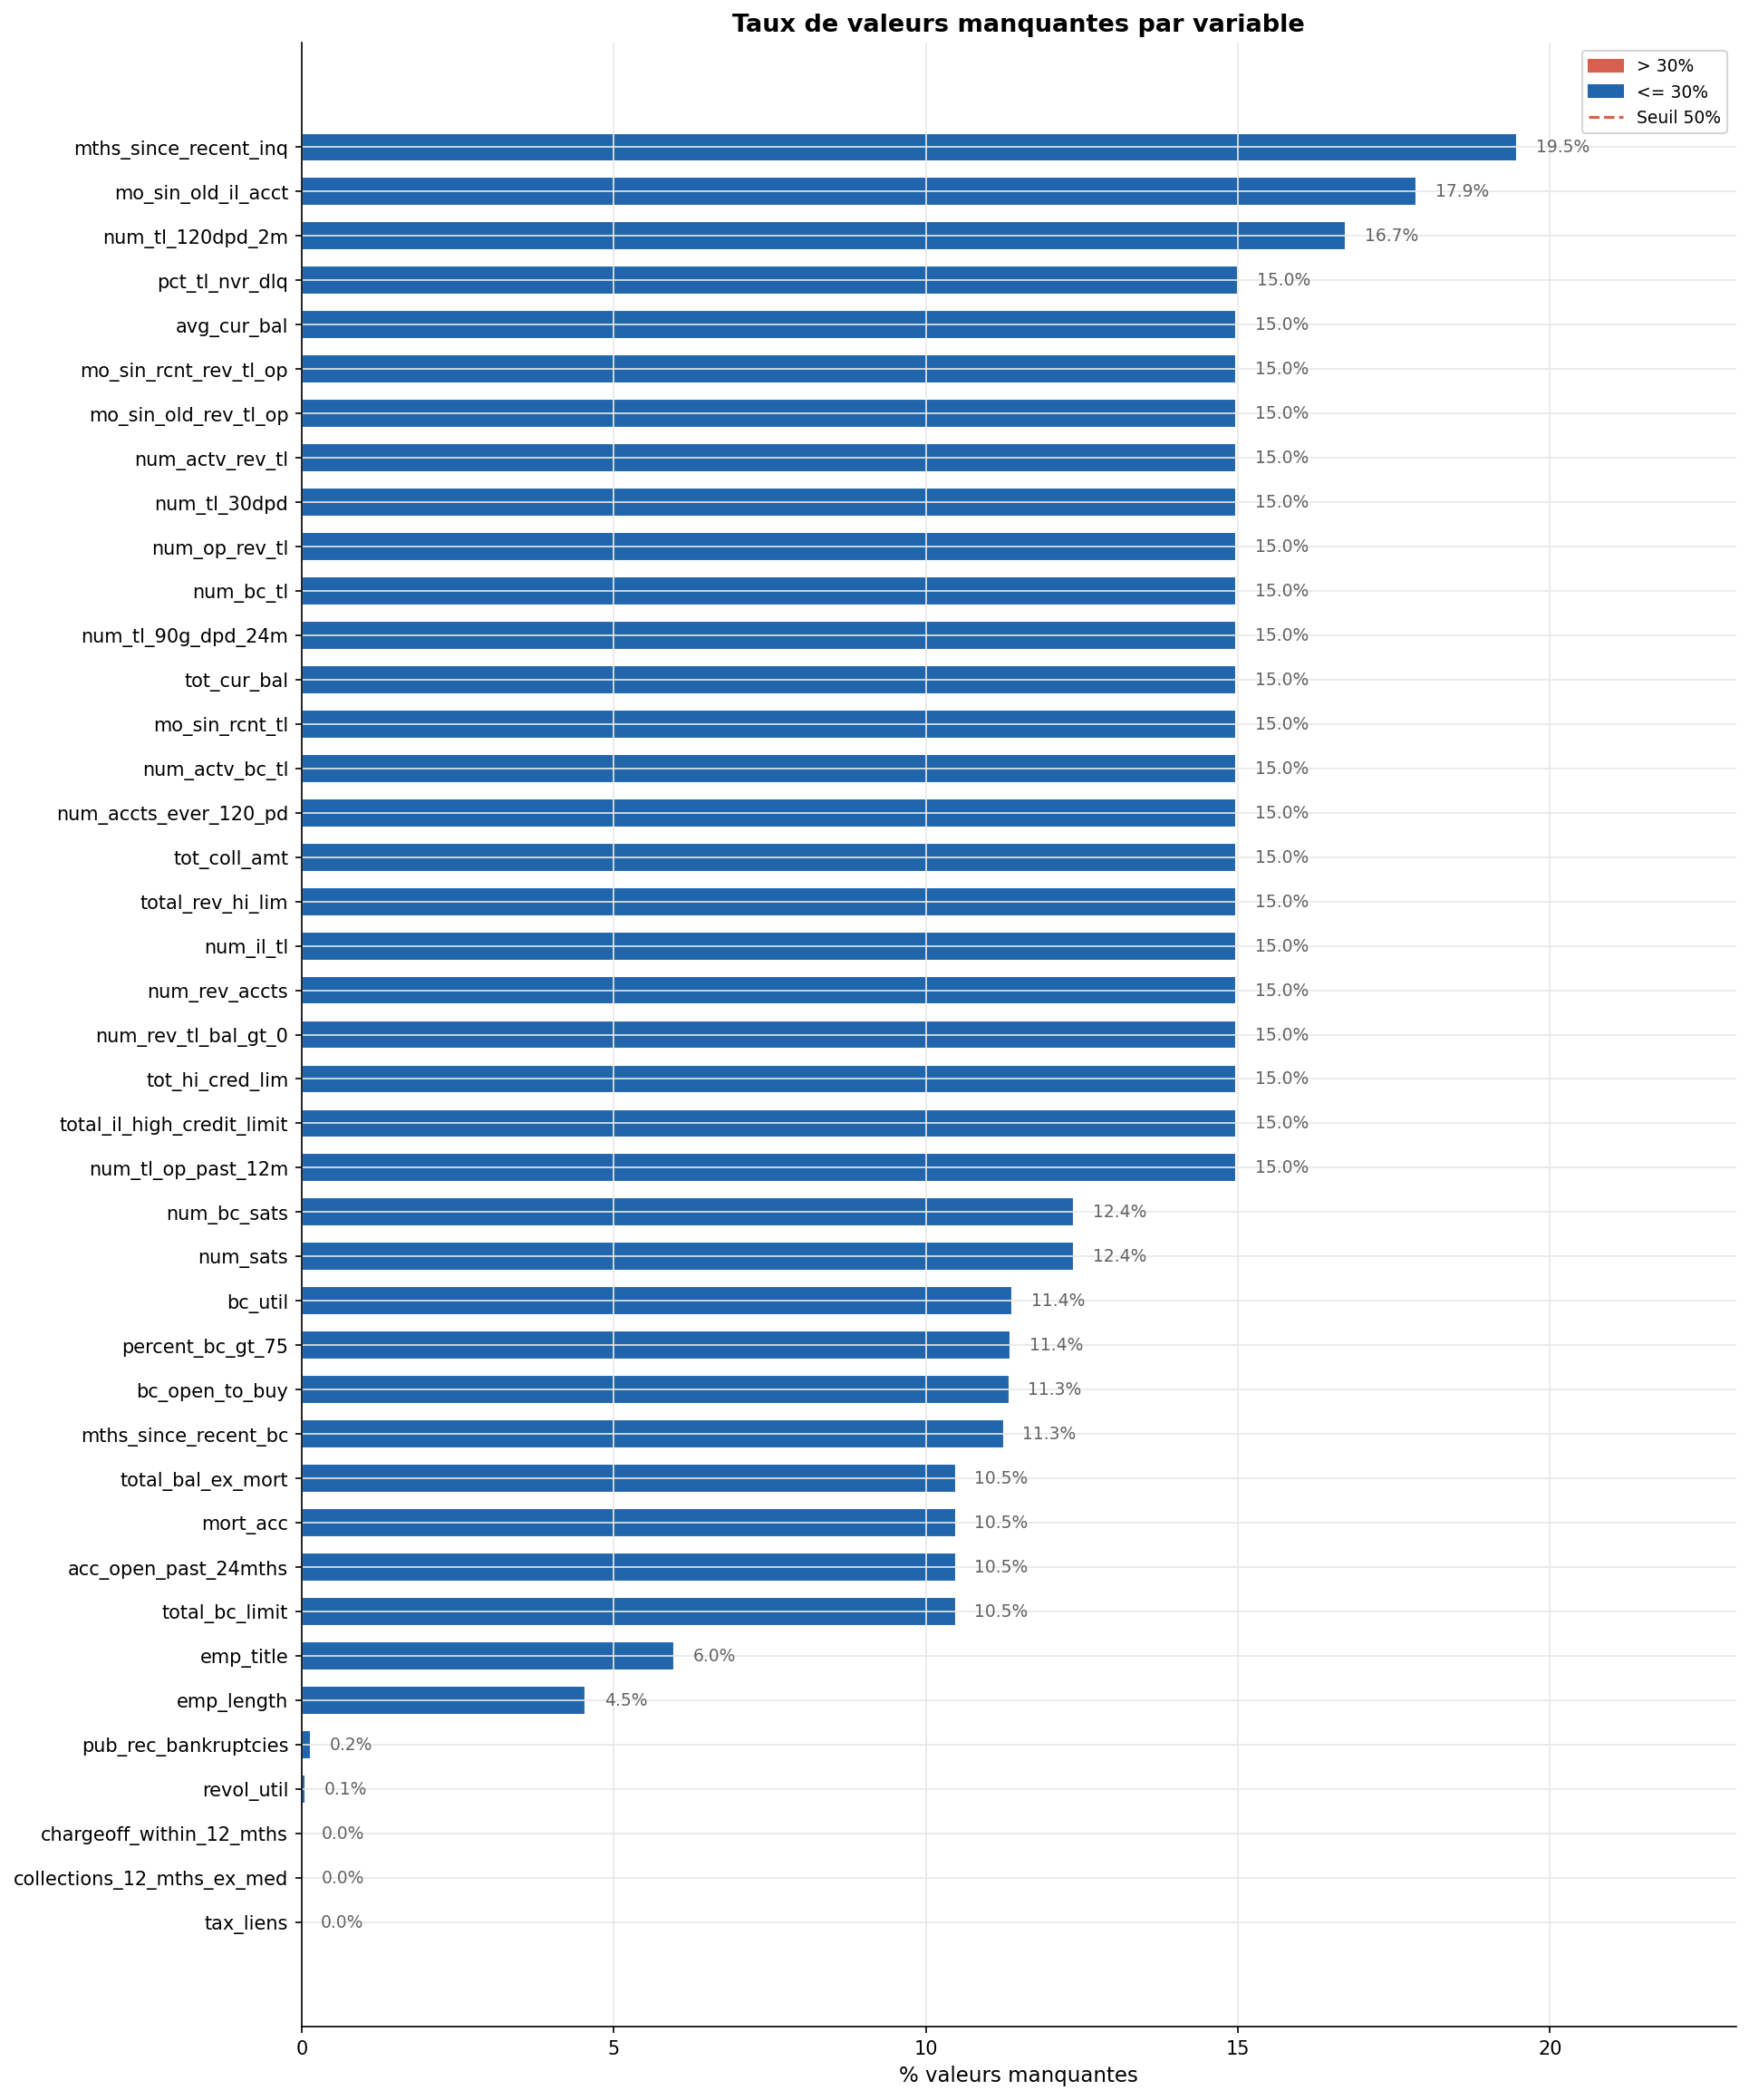

In [9]:
missing = (data.isnull().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(13, max(5, len(missing)*0.38)))
bar_colors = [RED if v > 30 else BLUE for v in missing.values]
bars = ax.barh(missing.index[::-1], missing.values[::-1],
               color=bar_colors[::-1], edgecolor='white', height=0.65)
for bar, val in zip(bars, missing.values[::-1]):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9, color=GRAY)
ax.axvline(50, color=RED, linestyle='--', lw=1.5)
ax.set_xlim(0, missing.max()*1.18)
ax.set_xlabel("% valeurs manquantes")
ax.set_title("Taux de valeurs manquantes par variable")
h1 = mpatches.Patch(color=RED,  label='> 30%')
h2 = mpatches.Patch(color=BLUE, label='<= 30%')
h3 = plt.Line2D([0],[0], color=RED, linestyle='--', label='Seuil 50%')
ax.legend(handles=[h1,h2,h3], fontsize=9)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('01_missing_values.png', bbox_inches='tight', facecolor='white')
plt.show()

> **Décision** : Les variables avec >50% de NaN ont déjà été supprimées à l'étape 4. Pour les variables restantes avec des NaN, on appliquera une **imputation par la médiane** à l'étape de préparation des features (avant la modélisation).

### 6.3 Répartition de la variable cible

**Q** : Le dataset est-il déséquilibré entre Fully Paid et Charged Off ?

**C** : Pie chart et barplot avec volumes annotés.

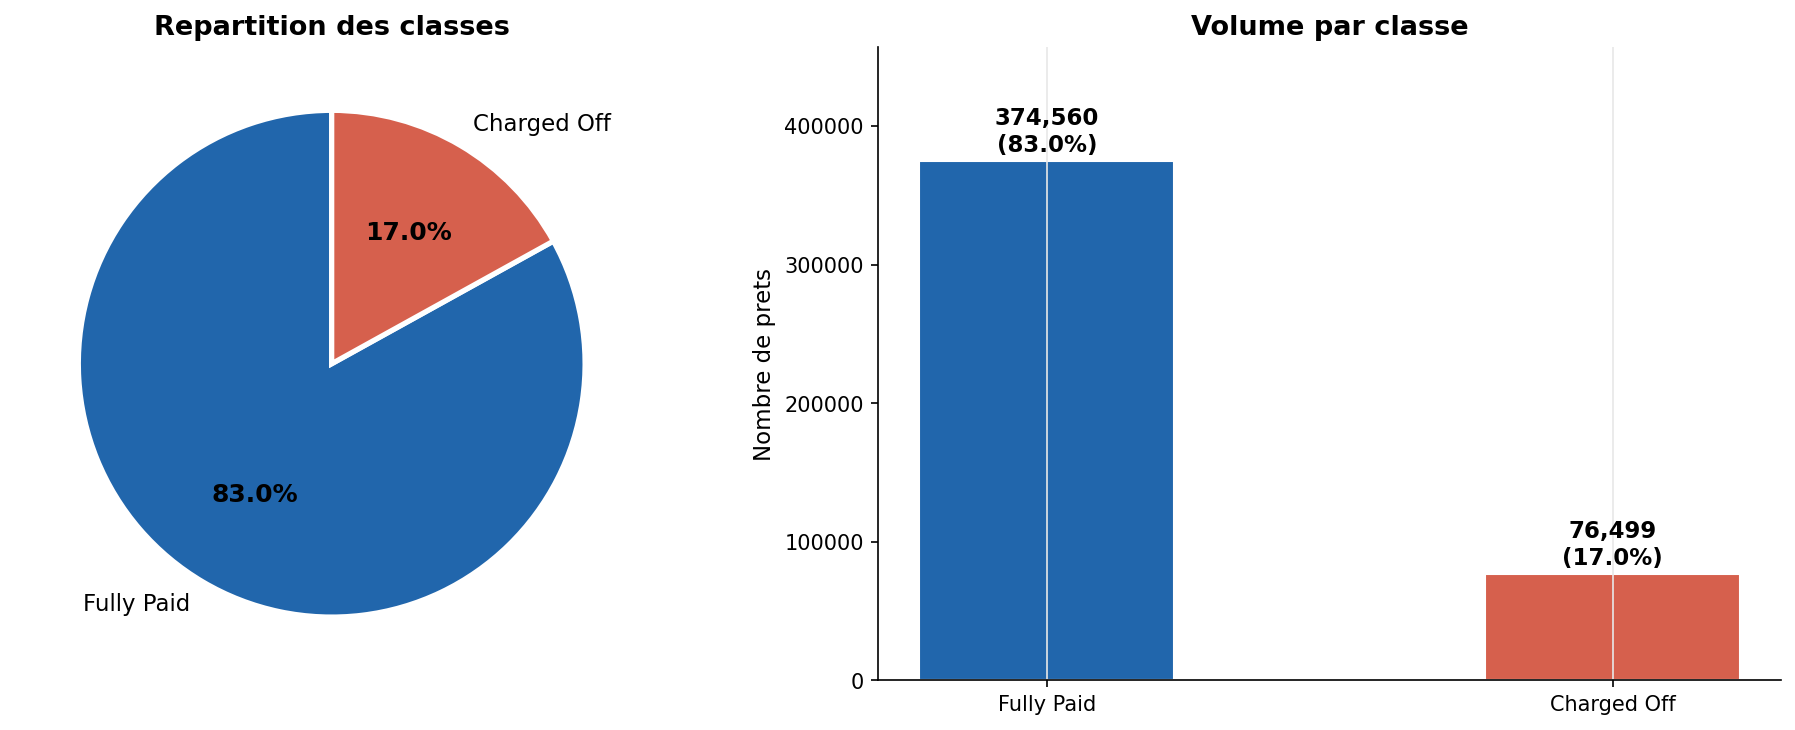

In [10]:
counts = data['target'].value_counts().sort_index()
labels = ['Fully Paid', 'Charged Off']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

wedges, texts, autotexts = axes[0].pie(
    counts, labels=labels, autopct='%1.1f%%',
    colors=[BLUE, RED], startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(12)
axes[0].set_title('Repartition des classes')

bars = axes[1].bar(labels, counts.values, color=[BLUE,RED],
                   edgecolor='white', width=0.45)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+counts.max()*0.01,
                 f"{val:,}\n({val/counts.sum()*100:.1f}%)",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, counts.max()*1.22)
axes[1].set_ylabel('Nombre de prets')
axes[1].set_title('Volume par classe')
axes[1].grid(axis='y')
plt.tight_layout()
plt.savefig('02_target_distribution.png', bbox_inches='tight', facecolor='white')
plt.show()

> **Observation** : Le dataset est **fortement déséquilibré** — les Fully Paid représentent environ 80% des prêts. Ce déséquilibre sera pris en compte dans la modélisation via `class_weight='balanced'` ou `scale_pos_weight`.

### 6.4 Distributions des variables numériques

**Q** : Les distributions des variables numériques diffèrent-elles entre Fully Paid et Charged Off ?

**C** : Courbes de densité (KDE) avec médianes annotées. Les courbes normalisées permettent une comparaison juste malgré le déséquilibre des classes.

In [ ]:
num_vars = [v for v in ['loan_amnt','annual_inc','dti','fico_range_low',
                         'revol_util','open_acc','installment','delinq_2yrs']
            if v in data.columns]

ncols = 4
nrows = -(-len(num_vars) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*4.5))
fig.patch.set_facecolor('white')
axes = axes.flatten()
d0_all = data[data['target']==0]
d1_all = data[data['target']==1]

for i, col in enumerate(num_vars):
    ax = axes[i]
    d0 = d0_all[col].dropna(); d1 = d1_all[col].dropna()
    cap = data[col].quantile(0.98)
    d0 = d0[d0<=cap]; d1 = d1[d1<=cap]
    d0.plot(kind='kde', ax=ax, color=BLUE, lw=2.5, label='Fully Paid')
    d1.plot(kind='kde', ax=ax, color=RED,  lw=2.5, linestyle='--', label='Charged Off')
    ax.axvline(d0.median(), color=BLUE, lw=1.2, linestyle=':', alpha=0.9,
               label=f'Med.FP: {d0.median():.0f}')
    ax.axvline(d1.median(), color=RED,  lw=1.2, linestyle=':', alpha=0.9,
               label=f'Med.CO: {d1.median():.0f}')
    ax.set_title(col); ax.set_ylabel('Densite', fontsize=9)
    ax.legend(fontsize=7.5)
    ax.spines[['top','right']].set_visible(False)

for j in range(len(num_vars), len(axes)): axes[j].set_visible(False)
fig.suptitle('Distributions - Fully Paid vs Charged Off', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('03_numeric_distributions.png', bbox_inches='tight', facecolor='white')
plt.show()

> **Observation** : Le **score FICO** et le **DTI** (ratio dette/revenu) montrent les écarts les plus marqués entre les deux classes. Les emprunteurs en défaut ont un score FICO médian plus bas et un DTI plus élevé — cohérent avec le risque de crédit.

### 6.5 Taux de défaut par variables catégorielles

**Q** : Certaines catégories d'emprunteurs présentent-elles un risque de défaut significativement plus élevé ?

**C** : Pour chaque variable catégorielle, on calcule le taux de défaut par modalité et on le compare à la moyenne globale (ligne pointillée noire). Les barres rouges dépassent la moyenne.

In [ ]:
cat_eda = {k: v for k, v in {
    'home_ownership':      'Statut logement',
    'verification_status': 'Verification du revenu',
    'purpose':             'Motif du pret',
    'term':                'Duree du pret',
}.items() if k in data.columns}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for i, (col, title) in enumerate(cat_eda.items()):
    ax = axes[i]
    agg = (data.groupby(col)['target'].agg(dr='mean', n='count')
           .reset_index().sort_values('dr'))
    agg['dr_pct'] = agg['dr'] * 100
    bar_colors = [RED if v > global_rate else BLUE for v in agg['dr_pct']]
    bars = ax.barh(agg[col].astype(str), agg['dr_pct'],
                   color=bar_colors, edgecolor='white', height=0.6)
    for bar, row in zip(bars, agg.itertuples()):
        ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                f"{row.dr_pct:.1f}%  (n={row.n:,})",
                va='center', fontsize=9, color=GRAY)
    ax.axvline(global_rate, color='black', linestyle='--',
               lw=1.3, label=f'Moy. {global_rate:.1f}%')
    ax.set_xlim(0, agg['dr_pct'].max()*1.4)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(title); ax.set_xlabel('Taux de defaut (%)')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Taux de defaut par variables categorielles',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('04_categorical_default_rates.png', bbox_inches='tight', facecolor='white')
plt.show()

> **Observation** : Les prêts sur **60 mois** affichent un taux de défaut nettement supérieur aux prêts sur 36 mois. Les prêts pour **small_business** et **renewable_energy** sont les motifs les plus risqués. Les revenus **non vérifiés** présentent paradoxalement un taux légèrement plus bas — probablement un biais de sélection.

### 6.6 Taux de défaut par état américain

Analyse géographique du risque de défaut à l'échelle des 50 états.

In [ ]:
if 'addr_state' in data.columns:
    state_agg = (data.groupby('addr_state')['target']
                 .agg(dr='mean', n='count').reset_index().sort_values('dr'))
    state_agg['dr_pct'] = state_agg['dr'] * 100

    fig, ax = plt.subplots(figsize=(13, max(10, len(state_agg)*0.35)))
    fig.patch.set_facecolor('white')
    bar_colors = [RED if v > global_rate else BLUE for v in state_agg['dr_pct']]
    ax.barh(state_agg['addr_state'], state_agg['dr_pct'],
            color=bar_colors, edgecolor='white', height=0.7)
    ax.axvline(global_rate, color='black', linestyle='--',
               lw=1.3, label=f'Moy. {global_rate:.1f}%')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title('Taux de defaut par Etat (addr_state)')
    ax.set_xlabel('Taux de defaut (%)')
    ax.legend(fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('05_default_by_state.png', bbox_inches='tight', facecolor='white')
    plt.show()

### 6.7 Boxplots — Variables numériques vs statut du prêt

**Q** : Les distributions des variables numériques clés sont-elles différentes entre les deux classes ?

**C** : Boxplots avec outliers cappés au 99e percentile pour la lisibilité. La médiane est annotée en blanc sur chaque boîte.

In [ ]:
box_vars = [v for v in ['loan_amnt','dti','annual_inc','fico_range_low','revol_util']
            if v in data.columns]

fig, axes = plt.subplots(1, len(box_vars), figsize=(18, 6))
fig.patch.set_facecolor('white')

for i, col in enumerate(box_vars):
    ax = axes[i]
    df_box = data[[col,'target']].dropna()
    cap = df_box[col].quantile(0.99)
    df_box = df_box[df_box[col]<=cap]
    d0 = df_box[df_box['target']==0][col].values
    d1 = df_box[df_box['target']==1][col].values
    bp = ax.boxplot([d0,d1], patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5, color=GRAY),
                    capprops=dict(linewidth=1.5, color=GRAY),
                    flierprops=dict(marker='.', markersize=2, alpha=0.25, color=GRAY))
    bp['boxes'][0].set_facecolor(BLUE)
    bp['boxes'][1].set_facecolor(RED)
    med0, med1 = np.median(d0), np.median(d1)
    ax.text(1, med0, f"{med0:,.0f}", ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='white')
    ax.text(2, med1, f"{med1:,.0f}", ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='white')
    ax.set_xticks([1,2])
    ax.set_xticklabels(['Fully\nPaid','Charged\nOff'], fontsize=10)
    ax.set_title(col)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', color='#E8E8E8')

h1 = mpatches.Patch(color=BLUE, label='Fully Paid')
h2 = mpatches.Patch(color=RED,  label='Charged Off')
fig.legend(handles=[h1,h2], loc='upper center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5,1.02))
fig.suptitle('Boxplots - Variables numeriques vs statut du pret',
             fontsize=15, fontweight='bold', y=1.06)
plt.tight_layout()
plt.savefig('06_boxplots_vs_target.png', bbox_inches='tight', facecolor='white')
plt.show()

> **Observation** : Le **score FICO** est clairement plus élevé pour les Fully Paid. Le **DTI** est légèrement plus élevé pour les Charged Off. Le montant du prêt (`loan_amnt`) présente une différence modérée.

### 6.8 Matrice de corrélation

**Q** : Existe-t-il des corrélations fortes entre les variables numériques ?

**C** : Heatmap triangulaire inférieure avec palette divergente centrée sur 0. Les corrélations fortes entre variables prédicteurs peuvent signaler une redondance.

In [ ]:
corr_vars = [c for c in ['loan_amnt','installment','annual_inc','dti',
                          'fico_range_low','fico_range_high','revol_util',
                          'open_acc','total_acc','delinq_2yrs','pub_rec','target']
             if c in data.columns]
corr = data[corr_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('white')
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.6, linecolor='white',
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.75, 'label': 'Correlation'})
ax.set_title('Matrice de correlation')
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)
plt.tight_layout()
plt.savefig('07_correlation_matrix.png', bbox_inches='tight', facecolor='white')
plt.show()

> **Observation** : `loan_amnt` et `installment` sont fortement corrélés (>0.95) — logique car la mensualité dépend du montant. De même, `fico_range_low` et `fico_range_high` sont quasi-identiques. On pourra n'en garder qu'une lors de la préparation des features.

### 6.9 Score FICO et taux de défaut

**Q** : Le score FICO est-il un bon prédicteur du défaut ?

**C** : On découpe le score FICO en tranches et on calcule le taux de défaut par tranche. Le dégradé Rouge→Bleu illustre la relation inverse entre score et risque.

In [ ]:
if 'fico_range_low' in data.columns and 'fico_range_high' in data.columns:
    data['fico_mid'] = (data['fico_range_low'] + data['fico_range_high']) / 2
    data['fico_bucket'] = pd.cut(data['fico_mid'],
        bins=[580,620,660,700,740,780,820,860],
        labels=['580-620','620-660','660-700','700-740','740-780','780-820','820-860'])
    fico_agg = (data.groupby('fico_bucket', observed=True)['target']
                .agg(dr='mean', n='count').reset_index())
    fico_agg['dr_pct'] = fico_agg['dr'] * 100
    n_b = len(fico_agg)
    palette = [plt.cm.RdYlBu(i/(n_b-1)) for i in range(n_b-1,-1,-1)]

    fig, ax1 = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')
    bars = ax1.bar(range(n_b), fico_agg['dr_pct'], color=palette,
                   edgecolor='white', width=0.6, zorder=3)
    for bar, val in zip(bars, fico_agg['dr_pct']):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax2 = ax1.twinx()
    ax2.plot(range(n_b), fico_agg['n'], color=GRAY, marker='o',
             lw=2, markersize=7, label='Nb prets', zorder=4)
    for xi, val in enumerate(fico_agg['n']):
        ax2.text(xi, val+fico_agg['n'].max()*0.02,
                 f"{val:,}", ha='center', fontsize=8.5, color=GRAY)
    ax2.set_ylabel('Nombre de prets', fontsize=11, color=GRAY)
    ax2.tick_params(axis='y', labelcolor=GRAY); ax2.grid(False)
    ax1.axhline(global_rate, color='black', linestyle='--',
                lw=1.3, label=f'Moy. {global_rate:.1f}%')
    ax1.set_xticks(range(n_b))
    ax1.set_xticklabels(fico_agg['fico_bucket'].astype(str), fontsize=11)
    ax1.set_xlabel('Tranche FICO', fontsize=11)
    ax1.set_ylabel('Taux de defaut (%)', fontsize=11)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.set_ylim(0, fico_agg['dr_pct'].max()*1.3)
    ax1.set_title('Taux de defaut et volume par tranche FICO')
    ax1.spines[['top','right']].set_visible(False)
    h_line = plt.Line2D([0],[0], color='black', linestyle='--', label=f'Moy. {global_rate:.1f}%')
    h_vol  = plt.Line2D([0],[0], color=GRAY, marker='o', lw=2, label='Nb prets')
    ax1.legend(handles=[h_line, h_vol], fontsize=10, loc='upper right')
    plt.tight_layout()
    plt.savefig('08_fico_vs_default.png', bbox_inches='tight', facecolor='white')
    plt.show()
    data.drop(columns=['fico_mid','fico_bucket'], inplace=True)

> **Observation** : La relation est **clairement monotone décroissante** — plus le score FICO est élevé, moins le risque de défaut est important. Les emprunteurs avec un score inférieur à 660 présentent un taux de défaut bien au-dessus de la moyenne.

### 6.10 Ancienneté professionnelle (emp_length)

**Q** : L'ancienneté professionnelle influence-t-elle le risque de défaut ?

**C** : Barplot du taux de défaut par tranche d'ancienneté, avec le volume en ligne grise.

In [ ]:
if 'emp_length' in data.columns:
    emp_map = {
        '< 1 year':'< 1 an','1 year':'1 an','2 years':'2 ans','3 years':'3 ans',
        '4 years':'4 ans','5 years':'5 ans','6 years':'6 ans','7 years':'7 ans',
        '8 years':'8 ans','9 years':'9 ans','10+ years':'10+ ans'
    }
    emp_order = ['< 1 an','1 an','2 ans','3 ans','4 ans','5 ans',
                 '6 ans','7 ans','8 ans','9 ans','10+ ans']
    data['emp_length_label'] = data['emp_length'].map(emp_map)
    emp_agg = (data.groupby('emp_length_label')['target']
               .agg(dr='mean', n='count').reset_index())
    emp_agg['dr_pct'] = emp_agg['dr'] * 100
    emp_agg['order'] = emp_agg['emp_length_label'].map({v:i for i,v in enumerate(emp_order)})
    emp_agg = emp_agg.dropna(subset=['order']).sort_values('order')

    fig, ax1 = plt.subplots(figsize=(13, 6))
    fig.patch.set_facecolor('white')
    ax2 = ax1.twinx()
    x = np.arange(len(emp_agg))
    bar_colors = [RED if v > global_rate else BLUE for v in emp_agg['dr_pct']]
    bars = ax1.bar(x, emp_agg['dr_pct'], color=bar_colors, edgecolor='white',
                   width=0.6, zorder=3)
    for bar, val in zip(bars, emp_agg['dr_pct']):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f"{val:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.plot(x, emp_agg['n'], color=GRAY, marker='o', lw=2, markersize=6,
             label='Nb prets', zorder=4)
    ax2.set_ylabel('Nombre de prets', fontsize=11, color=GRAY)
    ax2.tick_params(axis='y', labelcolor=GRAY); ax2.grid(False)
    ax1.axhline(global_rate, color='black', linestyle='--', lw=1.3)
    ax1.set_xticks(x)
    ax1.set_xticklabels(emp_agg['emp_length_label'], fontsize=11)
    ax1.set_xlabel('Anciennete professionnelle', fontsize=11)
    ax1.set_ylabel('Taux de defaut (%)', fontsize=11)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.set_ylim(0, emp_agg['dr_pct'].max()*1.3)
    ax1.set_title('Taux de defaut par anciennete professionnelle')
    ax1.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('09_emp_length_vs_default.png', bbox_inches='tight', facecolor='white')
    plt.show()
    data.drop(columns=['emp_length_label'], inplace=True)

> **Observation** : Le taux de défaut est légèrement plus élevé pour les emprunteurs avec moins d'ancienneté (< 1 an). Les emprunteurs avec 10+ ans d'ancienneté représentent le groupe le plus important et présentent un risque proche de la moyenne.

### 6.11 Analyse par région géographique

**Q** : Existe-t-il des disparités géographiques dans le risque de défaut ?

**C** : On regroupe les 50 états en 4 grandes régions (Northeast, Midwest, South, West) selon la classification du US Census Bureau.

In [ ]:
if 'addr_state' in data.columns:
    state_region_map = {
        'ME':'Northeast','NH':'Northeast','VT':'Northeast','MA':'Northeast',
        'RI':'Northeast','CT':'Northeast','NY':'Northeast','NJ':'Northeast','PA':'Northeast',
        'OH':'Midwest','MI':'Midwest','IN':'Midwest','IL':'Midwest','WI':'Midwest',
        'MN':'Midwest','IA':'Midwest','MO':'Midwest','ND':'Midwest','SD':'Midwest',
        'NE':'Midwest','KS':'Midwest',
        'DE':'South','MD':'South','DC':'South','VA':'South','WV':'South',
        'NC':'South','SC':'South','GA':'South','FL':'South','KY':'South',
        'TN':'South','AL':'South','MS':'South','AR':'South','LA':'South',
        'OK':'South','TX':'South',
        'MT':'West','ID':'West','WY':'West','CO':'West','NM':'West',
        'AZ':'West','UT':'West','NV':'West','WA':'West','OR':'West',
        'CA':'West','AK':'West','HI':'West',
    }
    data['region'] = data['addr_state'].map(state_region_map).fillna('Other')
    region_agg = (data.groupby('region')['target']
                  .agg(dr='mean', n='count').reset_index().sort_values('dr'))
    region_agg['dr_pct'] = region_agg['dr'] * 100

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.patch.set_facecolor('white')
    bar_colors = [RED if v > global_rate else BLUE for v in region_agg['dr_pct']]
    bars = axes[0].barh(region_agg['region'], region_agg['dr_pct'],
                        color=bar_colors, edgecolor='white', height=0.5)
    for bar, row in zip(bars, region_agg.itertuples()):
        axes[0].text(bar.get_width()+0.15, bar.get_y()+bar.get_height()/2,
                     f"{row.dr_pct:.1f}%  (n={row.n:,})",
                     va='center', fontsize=10, color=GRAY)
    axes[0].axvline(global_rate, color='black', linestyle='--',
                    lw=1.3, label=f'Moy. {global_rate:.1f}%')
    axes[0].set_xlim(0, region_agg['dr_pct'].max()*1.4)
    axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
    axes[0].set_title('Taux de defaut par region')
    axes[0].set_xlabel('Taux de defaut (%)')
    axes[0].legend(fontsize=9)
    axes[0].spines[['top','right']].set_visible(False)
    axes[1].pie(region_agg['n'], labels=region_agg['region'], autopct='%1.1f%%',
                startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
                textprops=dict(fontsize=11))
    axes[1].set_title('Repartition du volume par region')
    fig.suptitle('Analyse par region geographique', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('10_region_vs_default.png', bbox_inches='tight', facecolor='white')
    plt.show()
    data.drop(columns=['region'], inplace=True)

> **Observation** : Les disparités régionales sont modérées. La région **South** tend à présenter un taux légèrement plus élevé. La région **West** concentre le plus grand volume de prêts (Californie notamment).

### 6.12 Détection des valeurs aberrantes

**Q** : Y a-t-il des valeurs aberrantes dans les variables numériques clés ?

**C** : On applique la **règle IQR** : une valeur est considérée aberrante si elle est en dehors de l'intervalle [Q1 - 1.5×IQR, Q3 + 1.5×IQR].

In [ ]:
outlier_vars = [v for v in ['annual_inc','loan_amnt','dti','revol_bal','installment']
                if v in data.columns]

outlier_summary = []
for col in outlier_vars:
    serie = data[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((serie < lower) | (serie > upper)).sum()
    pct = n_out / len(serie) * 100
    outlier_summary.append({'variable':col,'Q1':Q1,'Q3':Q3,
                             'borne_inf':lower,'borne_sup':upper,
                             'n_outliers':n_out,'pct_outliers':pct})
    print(f"  {col:<15} : {n_out:>6,} outliers ({pct:.1f}%)  "
          f"| borne inf={lower:,.0f}  borne sup={upper:,.0f}")

df_out = pd.DataFrame(outlier_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('white')
bar_colors = [RED if v > 5 else BLUE for v in df_out['pct_outliers']]
bars = axes[0].barh(df_out['variable'], df_out['pct_outliers'],
                    color=bar_colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, df_out['pct_outliers']):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f"{val:.1f}%", va='center', fontsize=10)
axes[0].axvline(5, color=RED, linestyle='--', lw=1.3, label='Seuil 5%')
axes[0].set_xlabel('% valeurs aberrantes')
axes[0].set_title('% outliers par variable (regle IQR)')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)
data[outlier_vars].boxplot(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue'),
    medianprops=dict(color=RED, linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.2, color=GRAY),
    whiskerprops=dict(linewidth=1.5), capprops=dict(linewidth=1.5)
)
axes[1].set_title('Distribution des variables (avec outliers)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].spines[['top','right']].set_visible(False)
axes[1].grid(axis='y', color='#E8E8E8')
fig.suptitle('Detection des valeurs aberrantes - Methode IQR',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('11_outliers.png', bbox_inches='tight', facecolor='white')
plt.show()

> **Décision** : On ne supprime **pas** les valeurs aberrantes.
> - XGBoost et Random Forest travaillent sur des seuils de coupure → naturellement robustes aux outliers
> - Les outliers sur `annual_inc` peuvent représenter des emprunteurs à hauts revenus légitimes
> - On cappe uniquement à 98-99% pour les **graphiques** (lisibilité), mais les données brutes sont conservées pour la modélisation

---
## 7. Résumé de l'EDA

| # | Graphique | Observation clé |
|---|---|---|
| 1 | Évolution temporelle | Taux de défaut élevé en 2007-2008 (crise), volume explose après 2012 |
| 2 | Valeurs manquantes | Variables >50% NaN supprimées, reste traité par imputation médiane |
| 3 | Répartition classes | ~80% Fully Paid / ~20% Charged Off → déséquilibre à compenser |
| 4 | KDE numériques | FICO et DTI : écarts les plus marqués entre classes |
| 5 | Catégorielles | Prêts 60 mois et small_business : risque élevé |
| 6 | Par état | Disparités géographiques modérées |
| 7 | Boxplots | FICO confirme son pouvoir discriminant |
| 8 | Corrélation | loan_amnt/installment et fico_low/fico_high très corrélés |
| 9 | FICO | Relation monotone décroissante claire avec le défaut |
| 10 | emp_length | Ancienneté < 1 an légèrement plus risquée |
| 11 | Région | South légèrement plus risqué, West plus volumieux |
| 12 | Outliers | Présents mais conservés — modèles robustes |

**→ Prochaine étape : Préparation des features et modélisation**

In [ ]:
print(f"Dataset final : {data.shape[0]:,} lignes x {data.shape[1]} colonnes")
print(f"Fully Paid  : {(data['target']==0).sum():,}  ({(data['target']==0).mean()*100:.1f}%)")
print(f"Charged Off : {(data['target']==1).sum():,}  ({(data['target']==1).mean()*100:.1f}%)")
print("\nEDA terminee - pret pour la modelisation")